# Parcial de Inteligencia Artificial
## Predicción de aprobación en Señales y Sistemas

### Pregunta de investigación
**¿Es posible predecir si un estudiante aprobará Señales y Sistemas utilizando su nota del primer parcial y características de su rendimiento académico previo?**

### Criterio de aprobación utilizado

El resultado se reconstruye desde `Nota.Final`:

- `1F-2` → nota 2 → **aprobado**.
- `2F-1` → nota 1 → **no aprobado**.
- `1F-1,2F-4` → existe un final con nota 4 → **aprobado**.
- Nota mínima para aprobar: **2**.
- Nota máxima: **5**.
- Si `Nota.Final` está vacío o no contiene una nota aprobatoria, se considera **no aprobado** dentro del período observado.

Formalmente:

`Aprobado_calculado = 1` si existe al menos una nota final entre 2 y 5; en caso contrario, `0`.



## 0. Librerías

In [41]:
from pathlib import Path
import hashlib
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

RANDOM_STATE = 42

# 1. Carga de los cuatro ciclos


In [42]:
rutas_posibles = [
    Path("/content"),
    Path("/mnt/data/ia_work/BaseDatos1P"),
    Path("BaseDatos1P")
]

DATA_DIR = next(
    (
        ruta for ruta in rutas_posibles
        if ruta.exists()
        and len(list(ruta.glob("*.xlsx"))) >= 4
    ),
    None
)

if DATA_DIR is None:
    raise FileNotFoundError(
        "No se encontraron los cuatro Excel. "
        "En Colab, súbelos al panel Archivos y vuelve a ejecutar."
    )

archivos = sorted([
    p for p in DATA_DIR.glob("*.xlsx")
    if "rendimiento" in p.name.lower()
])

print("Archivos encontrados:", len(archivos))
for archivo in archivos:
    print(" -", archivo.name)

if len(archivos) != 4:
    raise ValueError(
        f"Se esperaban 4 archivos de rendimiento y se encontraron {len(archivos)}."
    )

dfs = []

for archivo in archivos:
    temp = pd.read_excel(archivo)
    temp["archivo_origen"] = archivo.name
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True, sort=False)

print("\nDimensiones de la base completa:", df.shape)

print("\nRegistros por año y semestre:")
print(df.groupby(["Anho", "Semestre"]).size())

Archivos encontrados: 4
 - rendimiento_aдo_2024_ciclo_1_anon.xlsx
 - rendimiento_aдo_2024_ciclo_2_anon.xlsx
 - rendimiento_aдo_2025_ciclo_1_anon.xlsx
 - rendimiento_aдo_2025_ciclo_2_anon.xlsx

Dimensiones de la base completa: (87147, 31)

Registros por año y semestre:
Anho  Semestre
2024  1           22852
      2           24468
2025  1           19407
      2           20420
dtype: int64


# 2. Limpieza y normalización

Los Excel contienen algunos espacios al final de los códigos de plan.  
Además, se normalizan tildes y la `ñ` para evitar errores al filtrar nombres.

In [43]:
columnas_texto = [
    "ALUMNO_ID",
    "Cod.Asign",
    "Asignatura",
    "Cod.Car.Sec",
    "Aprobado",
    "Nota.Final"
]

for col in columnas_texto:
    if col in df.columns:
        df[col] = df[col].astype("string").str.strip()


def normalizar_texto(valor):
    if pd.isna(valor):
        return ""

    texto = str(valor).strip().upper()

    texto = unicodedata.normalize("NFKD", texto)
    texto = texto.encode("ascii", "ignore").decode("ascii")
    texto = re.sub(r"\s+", " ", texto)

    return texto


df["Asignatura_norm"] = df["Asignatura"].map(normalizar_texto)

df["Plan_norm"] = (
    df["Cod.Car.Sec"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace("_", "-", regex=False)
)

print("Normalización completada.")

Normalización completada.


# 3. Reconstrucción del resultado desde `Nota.Final`

Una cadena como:

`1F-1,2F-4`

contiene dos calificaciones finales: 1 y 4.

Para decidir aprobación se revisan **todas** las notas registradas, porque en la base el orden textual no siempre coincide con el número de final.  
Si existe al menos una nota `>= 2`, el alumno aprobó.



In [44]:
def extraer_notas_finales(valor):
    if pd.isna(valor):
        return []

    coincidencias = re.findall(
        r"(\d+)\s*F\s*-\s*([1-5])",
        str(valor).upper()
    )

    return [int(nota) for _, nota in coincidencias]


def nota_final_numerica(valor):
    notas = extraer_notas_finales(valor)

    if len(notas) == 0:
        return np.nan

    return float(max(notas))


def aprobado_desde_nota_final(valor):
    notas = extraer_notas_finales(valor)

    return int(
        any(nota >= 2 for nota in notas)
    )


df["NotaFinal_num"] = df["Nota.Final"].apply(
    nota_final_numerica
)

df["Aprobado_nf"] = df["Nota.Final"].apply(
    aprobado_desde_nota_final
)

print("Ejemplos:")
ejemplos = pd.Series([
    "2F-1",
    "1F-2",
    "1F-1,2F-4",
    "3F-2,2F-1",
    np.nan
])

tabla_ejemplo = pd.DataFrame({
    "Nota.Final": ejemplos,
    "NotaFinal_num": ejemplos.apply(nota_final_numerica),
    "Aprobado_calculado": ejemplos.apply(aprobado_desde_nota_final)
})

display(tabla_ejemplo)

Ejemplos:


,Nota.Final,NotaFinal_num,Aprobado_calculado
0,2F-1,1.000,0
1,1F-2,2.000,1
2,"1F-1,2F-4",4.000,1
3,"3F-2,2F-1",2.000,1
4,NaN,NaN,0


# 4. Filtrado de Señales y Sistemas

Planes utilizados:

- `MCT-PLS13`: malla vieja.
- `MCT-PLS23`: malla nueva.

In [45]:
mask_senales = (
    (df["Asignatura_norm"] == "SENALES Y SISTEMAS")
    &
    (df["Plan_norm"].isin([
        "MCT-PLS13",
        "MCT-PLS23"
    ]))
)

senales_raw = df.loc[mask_senales].copy()

if senales_raw.empty:
    raise ValueError(
        "No se encontraron registros de Señales y Sistemas."
    )

print("Registros encontrados:", len(senales_raw))
print("ALUMNO_ID distintos:", senales_raw["ALUMNO_ID"].nunique())

print("\nPor año y semestre:")
print(senales_raw.groupby(["Anho", "Semestre"]).size())

print("\nPor malla:")
print(senales_raw["Plan_norm"].value_counts())

Registros encontrados: 98
ALUMNO_ID distintos: 82

Por año y semestre:
Anho  Semestre
2024  2           60
2025  2           38
dtype: int64

Por malla:
Plan_norm
MCT-PLS13    72
MCT-PLS23    26
Name: count, dtype: int64


## 4.1. Verificación del criterio de aprobación

Aquí se compara:

- `Aprobado`: columna original de la base.
- `Aprobado_nf`: variable reconstruida únicamente desde `Nota.Final`.

Para **Señales y Sistemas**, ambas deberían coincidir en los datos proporcionados.

In [46]:
senales_raw["Aprobado_original_num"] = (
    senales_raw["Aprobado"]
    .astype(str)
    .str.upper()
    .str.strip()
    .map({"S": 1, "N": 0})
)

comparacion_target = pd.crosstab(
    senales_raw["Aprobado_original_num"],
    senales_raw["Aprobado_nf"],
    rownames=["Aprobado original"],
    colnames=["Aprobado desde Nota.Final"]
)

display(comparacion_target)

coincidencia = (
    senales_raw["Aprobado_original_num"]
    == senales_raw["Aprobado_nf"]
).mean() * 100

print(f"Coincidencia en Señales y Sistemas: {coincidencia:.1f}%")

Aprobado desde Nota.Final,0,1
Aprobado original,,
0,34,0
1,0,64


Coincidencia en Señales y Sistemas: 100.0%


In [49]:
# ============================================================
# LOS 98 REGISTROS ORIGINALES DE SEÑALES Y SISTEMAS
# + RENDIMIENTO DEL SEMESTRE ANTERIOR
# ============================================================

revision_98 = senales_raw.copy().reset_index(drop=True)

materias_cursadas_lista = []
materias_aprobadas_lista = []
tasa_aprobacion_lista = []

for _, fila in revision_98.iterrows():

    alumno_id = fila["ALUMNO_ID"]
    anho = int(fila["Anho"])
    semestre = int(fila["Semestre"])

    # Buscar el semestre inmediatamente anterior
    anterior = df[
        (df["ALUMNO_ID"] == alumno_id)
        &
        (df["Anho"] == anho)
        &
        (df["Semestre"] == semestre - 1)
    ].copy()

    # Contar cada asignatura una sola vez
    anterior = anterior.drop_duplicates("Cod.Asign")

    materias_cursadas = len(anterior)

    materias_aprobadas = int(
        anterior["Aprobado_nf"].sum()
    )

    if materias_cursadas > 0:
        tasa_aprobacion = (
            materias_aprobadas
            / materias_cursadas
        )
    else:
        tasa_aprobacion = np.nan

    materias_cursadas_lista.append(
        materias_cursadas
    )

    materias_aprobadas_lista.append(
        materias_aprobadas
    )

    tasa_aprobacion_lista.append(
        tasa_aprobacion
    )


# ============================================================
# AGREGAR FEATURES CALCULADAS
# ============================================================

revision_98["materias_cursadas_anterior"] = (
    materias_cursadas_lista
)

revision_98["materias_aprobadas_anterior"] = (
    materias_aprobadas_lista
)

revision_98["tasa_aprobacion_anterior"] = (
    tasa_aprobacion_lista
)


# ============================================================
# COLUMNAS QUE QUEREMOS VISUALIZAR
# ============================================================

columnas_mostrar = [
    "ALUMNO_ID",
    "Anho",
    "Semestre",

    # Materia analizada
    "Cod.Asign",
    "Asignatura",

    # Malla
    "Plan_norm",

    # Primer parcial de Señales y Sistemas
    "Primer.Par",

    # Feature engineering del semestre anterior
    "materias_cursadas_anterior",
    "materias_aprobadas_anterior",
    "tasa_aprobacion_anterior",

    # Resultado final
    "Nota.Final",
    "Aprobado_nf"
]


revision_98 = (
    revision_98[columnas_mostrar]
    .sort_values([
        "Anho",
        "Semestre",
        "ALUMNO_ID"
    ])
    .reset_index(drop=True)
)


# ============================================================
# MOSTRAR TODOS LOS REGISTROS
# ============================================================

pd.set_option(
    "display.max_rows",
    120
)

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_colwidth",
    None
)


print(
    "Registros originales de Señales y Sistemas:",
    len(senales_raw)
)

print(
    "Registros mostrados en la tabla:",
    len(revision_98)
)

print(
    "ALUMNO_ID distintos:",
    revision_98["ALUMNO_ID"].nunique()
)

display(revision_98)

Registros originales de Señales y Sistemas: 98
Registros mostrados en la tabla: 98
ALUMNO_ID distintos: 82


,ALUMNO_ID,Anho,Semestre,Cod.Asign,Asignatura,Plan_norm,Primer.Par,materias_cursadas_anterior,materias_aprobadas_anterior,tasa_aprobacion_anterior,Nota.Final,Aprobado_nf
0,FIUNA_ALUMNO_005685,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,23,6,4,0.667,"1F-1,2F-2",1
1,FIUNA_ALUMNO_005839,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,25,6,1,0.167,<NA>,0
2,FIUNA_ALUMNO_005927,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,55,5,4,0.800,"1F-1,2F-4",1
3,FIUNA_ALUMNO_006843,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,8,5,4,0.800,<NA>,0
4,FIUNA_ALUMNO_006920,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,35,5,2,0.400,<NA>,0
5,FIUNA_ALUMNO_007044,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,55,6,5,0.833,1F-3,1
6,FIUNA_ALUMNO_007055,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,53,6,5,0.833,1F-4,1
7,FIUNA_ALUMNO_007140,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,15,7,7,1.000,2F-3,1
8,FIUNA_ALUMNO_007196,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,0,2,0,0.000,<NA>,0
9,FIUNA_ALUMNO_007386,2024,2,13706,SEÑALES Y SISTEMAS,MCT-PLS13,23,6,4,0.667,"1F-1,2F-2",1


# 5. Control de perfiles académicos repetidos

En la base anonimizada aparecen distintos `ALUMNO_ID` con historiales académicos completos idénticos.

Para evitar que dos copias del mismo perfil queden una en entrenamiento y otra en prueba, se genera una **huella del historial académico**.

La implementación usa hashes para hacerlo de manera rápida.  
Para la defensa basta con explicar que se agrupan historiales idénticos para evitar duplicación y fuga de información entre train y test.

In [54]:
columnas_excluir_perfil = {
    "ALUMNO_ID",
    "archivo_origen",
    "Asignatura_norm",
    "Plan_norm",
    "NotaFinal_num",
    "Aprobado_nf"
}

columnas_perfil = [
    c for c in df.columns
    if c not in columnas_excluir_perfil
]

perfil_df = df[columnas_perfil].copy()

for col in perfil_df.columns:
    perfil_df[col] = (
        perfil_df[col]
        .astype("string")
        .fillna("<NA>")
    )

hash_fila = pd.util.hash_pandas_object(
    perfil_df,
    index=False
).astype("uint64")

tabla_hash = pd.DataFrame({
    "ALUMNO_ID": df["ALUMNO_ID"].astype(str),
    "hash_fila": hash_fila
})

firma_por_alumno = (
    tabla_hash
    .groupby("ALUMNO_ID")["hash_fila"]
    .agg(
        lambda valores:
        "|".join(
            map(str, sorted(valores.tolist()))
        )
    )
)

perfil_por_alumno = firma_por_alumno.map(
    lambda texto:
    hashlib.sha1(
        texto.encode("utf-8")
    ).hexdigest()
)

df["profile_group"] = (
    df["ALUMNO_ID"]
    .astype(str)
    .map(perfil_por_alumno)
)

senales_raw["profile_group"] = (
    senales_raw["ALUMNO_ID"]
    .astype(str)
    .map(perfil_por_alumno)
)


senales = (
    senales_raw
    .sort_values([
        "profile_group",
        "Anho",
        "Semestre",
        "ALUMNO_ID"
    ])
    .drop_duplicates([
        "profile_group",
        "Anho",
        "Semestre"
    ])
    .copy()
)

senales["malla_nueva"] = (
    senales["Plan_norm"] == "MCT-PLS23"
).astype(int)

# TARGET DEFINITIVO: sale de Nota.Final
senales["y"] = senales["Aprobado_nf"].astype(int)

print("Registros originales de Señales:", len(senales_raw))
print("Observaciones finales para modelado:", len(senales))
print("Perfiles académicos distintos:", senales["profile_group"].nunique())

print("\nTarget final:")
print(
    senales["y"]
    .value_counts()
    .rename(index={
        0: "No aprobó",
        1: "Aprobó"
    })
)

print(
    "\nPorcentaje de aprobación: "
    f"{100 * senales['y'].mean():.2f}%"
)

Registros originales de Señales: 98
Observaciones finales para modelado: 49
Perfiles académicos distintos: 41

Target final:
y
Aprobó       32
No aprobó    17
Name: count, dtype: int64

Porcentaje de aprobación: 65.31%


# 6. EDA — análisis exploratorio

La guía pide:

- dimensiones y tipos;
- valores faltantes;
- estadísticas principales;
- distribuciones;
- gráficos;
- breve interpretación.

Se incluyen varias visualizaciones inspiradas en el enfoque usado en los ejemplos del curso: barras por período, porcentajes anotados y mapas de calor, además de gráficos específicos para nuestro problema.

In [8]:
columnas_eda = [
    "Anho",
    "Semestre",
    "Plan_norm",
    "Primer.Par",
    "Nota.Final",
    "NotaFinal_num",
    "y"
]

print("Dimensiones:", senales[columnas_eda].shape)

print("\nTipos de variables:")
print(senales[columnas_eda].dtypes)

print("\nValores faltantes:")
print(
    senales[columnas_eda]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

print("\nEstadísticas del Primer Parcial:")
display(
    senales.groupby("y")["Primer.Par"]
    .describe()
    .rename(index={
        0: "No aprobó",
        1: "Aprobó"
    })
    .round(2)
)

Dimensiones: (49, 7)

Tipos de variables:
Anho                      int64
Semestre                  int64
Plan_norm                object
Primer.Par                int64
Nota.Final       string[python]
NotaFinal_num           float64
y                         int64
dtype: object

Valores faltantes:
Nota.Final       16
NotaFinal_num    16
Anho              0
Plan_norm         0
Semestre          0
Primer.Par        0
y                 0
dtype: int64

Estadísticas del Primer Parcial:


,count,mean,std,min,25%,50%,75%,max
y,,,,,,,,
No aprobó,17.000,19.470,19.230,0.000,0.000,23.000,38.000,50.000
Aprobó,32.000,58.340,23.320,0.000,47.250,56.500,75.750,100.000


## Gráfico 1 — Cantidad de aprobados y no aprobados

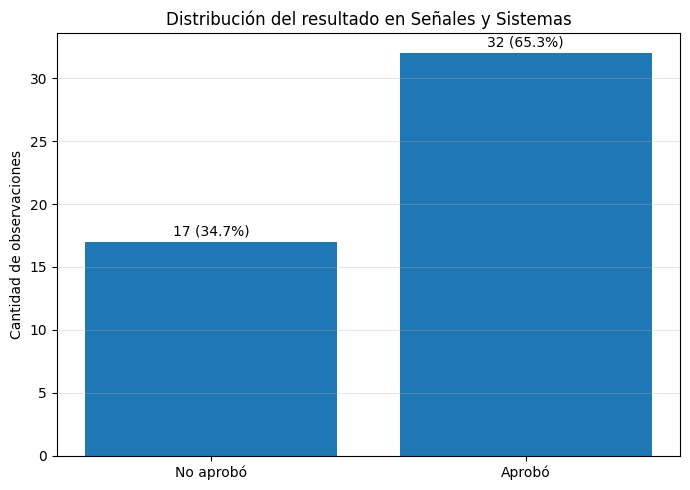

In [9]:
conteo_target = (
    senales["y"]
    .value_counts()
    .sort_index()
)

etiquetas = ["No aprobó", "Aprobó"]

plt.figure(figsize=(7, 5))
barras = plt.bar(
    etiquetas,
    conteo_target.values
)

total = conteo_target.sum()

for barra, valor in zip(barras, conteo_target.values):
    porcentaje = 100 * valor / total

    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.5,
        f"{valor} ({porcentaje:.1f}%)",
        ha="center"
    )

plt.title("Distribución del resultado en Señales y Sistemas")
plt.ylabel("Cantidad de observaciones")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Gráfico 2 — Porcentaje de aprobación por año

Es análogo a los gráficos por período utilizados en el material del curso.

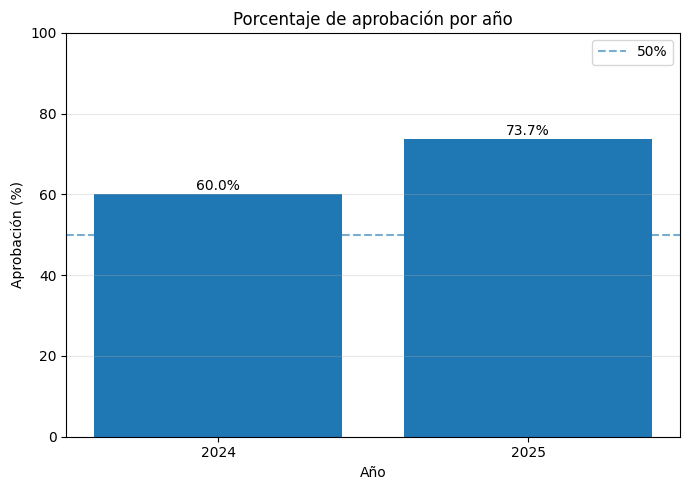

,Anho,count,sum,mean,porcentaje
0,2024,30,18,0.600,60.000
1,2025,19,14,0.737,73.684


In [10]:
aprobacion_anho = (
    senales.groupby("Anho")["y"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

aprobacion_anho["porcentaje"] = (
    aprobacion_anho["mean"] * 100
)

plt.figure(figsize=(7, 5))

barras = plt.bar(
    aprobacion_anho["Anho"].astype(str),
    aprobacion_anho["porcentaje"]
)

for barra, valor in zip(
    barras,
    aprobacion_anho["porcentaje"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 1,
        f"{valor:.1f}%",
        ha="center"
    )

plt.axhline(
    50,
    linestyle="--",
    alpha=0.6,
    label="50%"
)

plt.ylim(0, 100)
plt.xlabel("Año")
plt.ylabel("Aprobación (%)")
plt.title("Porcentaje de aprobación por año")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(aprobacion_anho.round(3))

## Gráfico 3 — Porcentaje de aprobación por malla

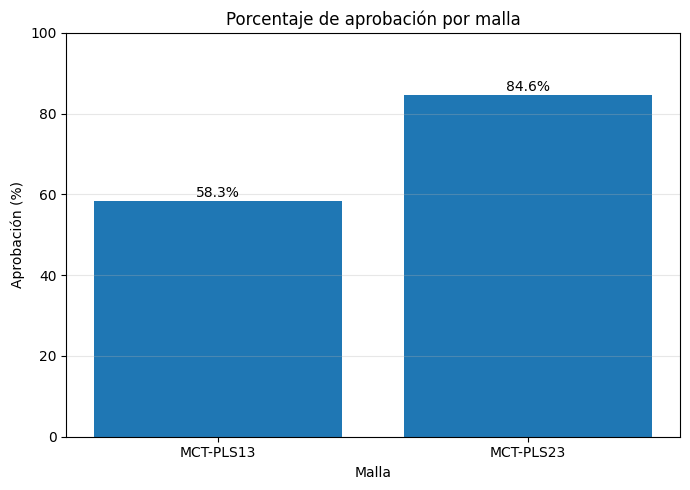

,Plan_norm,count,sum,mean,porcentaje
0,MCT-PLS13,36,21,0.583,58.333
1,MCT-PLS23,13,11,0.846,84.615


In [11]:
tabla_malla = (
    senales.groupby("Plan_norm")["y"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

tabla_malla["porcentaje"] = (
    tabla_malla["mean"] * 100
)

plt.figure(figsize=(7, 5))

barras = plt.bar(
    tabla_malla["Plan_norm"],
    tabla_malla["porcentaje"]
)

for barra, valor in zip(
    barras,
    tabla_malla["porcentaje"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 1,
        f"{valor:.1f}%",
        ha="center"
    )

plt.ylim(0, 100)
plt.ylabel("Aprobación (%)")
plt.xlabel("Malla")
plt.title("Porcentaje de aprobación por malla")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

display(tabla_malla.round(3))

## Gráfico 4 — Distribución de la nota del Primer Parcial

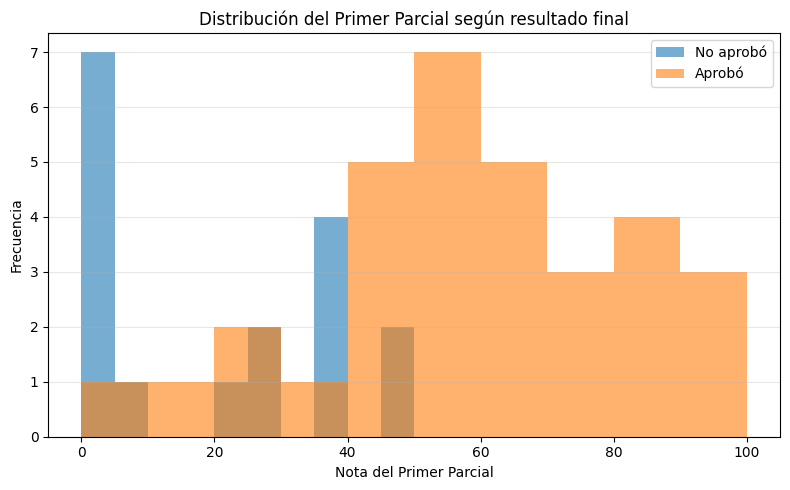

In [12]:
plt.figure(figsize=(8, 5))

plt.hist(
    senales.loc[senales["y"] == 0, "Primer.Par"],
    bins=10,
    alpha=0.6,
    label="No aprobó"
)

plt.hist(
    senales.loc[senales["y"] == 1, "Primer.Par"],
    bins=10,
    alpha=0.6,
    label="Aprobó"
)

plt.xlabel("Nota del Primer Parcial")
plt.ylabel("Frecuencia")
plt.title("Distribución del Primer Parcial según resultado final")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Gráfico 5 — Boxplot del Primer Parcial

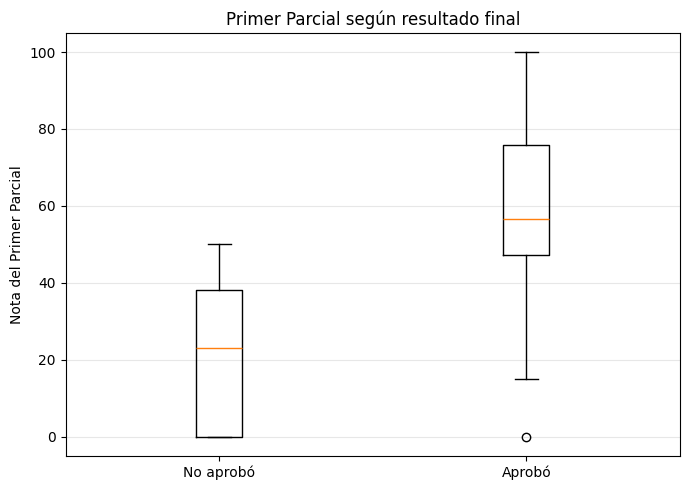

Media P1 - No aprobó: 19.47
Media P1 - Aprobó: 58.34


In [13]:
p1_no = (
    senales.loc[
        senales["y"] == 0,
        "Primer.Par"
    ]
    .dropna()
)

p1_si = (
    senales.loc[
        senales["y"] == 1,
        "Primer.Par"
    ]
    .dropna()
)

plt.figure(figsize=(7, 5))

plt.boxplot(
    [p1_no, p1_si],
    tick_labels=[
        "No aprobó",
        "Aprobó"
    ]
)

plt.ylabel("Nota del Primer Parcial")
plt.title("Primer Parcial según resultado final")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(
    "Media P1 - No aprobó:",
    round(p1_no.mean(), 2)
)

print(
    "Media P1 - Aprobó:",
    round(p1_si.mean(), 2)
)

# 7. Feature engineering del semestre anterior

Para cada estudiante de Señales y Sistemas se consulta el semestre inmediatamente anterior.

Se construyen:

- `materias_cursadas_anterior`
- `materias_aprobadas_anterior`
- `tasa_aprobacion_anterior`

La aprobación de las materias previas también se calcula a partir de `Nota.Final >= 2`, manteniendo el mismo criterio del target.

In [33]:
filas_historial = []

for _, fila in senales.iterrows():

    alumno_id = fila["ALUMNO_ID"]
    anho = int(fila["Anho"])
    semestre = int(fila["Semestre"])

    anterior = df[
        (df["ALUMNO_ID"] == alumno_id)
        &
        (df["Anho"] == anho)
        &
        (df["Semestre"] == semestre - 1)
    ].copy()

    # Una asignatura se cuenta una vez
    anterior = anterior.drop_duplicates(
        "Cod.Asign"
    )

    cursadas = len(anterior)

    aprobadas = int(
        anterior["Aprobado_nf"].sum()
    )

    tasa = (
        aprobadas / cursadas
        if cursadas > 0
        else np.nan
    )

    filas_historial.append({
        "profile_group": fila["profile_group"],
        "Anho": fila["Anho"],
        "Semestre": fila["Semestre"],
        "materias_cursadas_anterior": cursadas,
        "materias_aprobadas_anterior": aprobadas,
        "tasa_aprobacion_anterior": tasa
    })

historial = pd.DataFrame(
    filas_historial
)

senales = senales.merge(
    historial,
    on=[
        "profile_group",
        "Anho",
        "Semestre"
    ],
    how="left"
)

print("Promedios según resultado final:")

display(
    senales.groupby("y")[
        [
            "Primer.Par",
            "materias_cursadas_anterior",
            "materias_aprobadas_anterior",
            "tasa_aprobacion_anterior"
        ]
    ]
    .mean()
    .rename(index={
        0: "No aprobó",
        1: "Aprobó"
    })
    .round(3)
)

Promedios según resultado final:


,Primer.Par,materias_cursadas_anterior,materias_aprobadas_anterior,tasa_aprobacion_anterior
y,,,,
No aprobó,19.471,4.353,2.059,0.467
Aprobó,58.344,4.906,4.156,0.842


## Gráfico 6 — Tasa de aprobación del semestre anterior

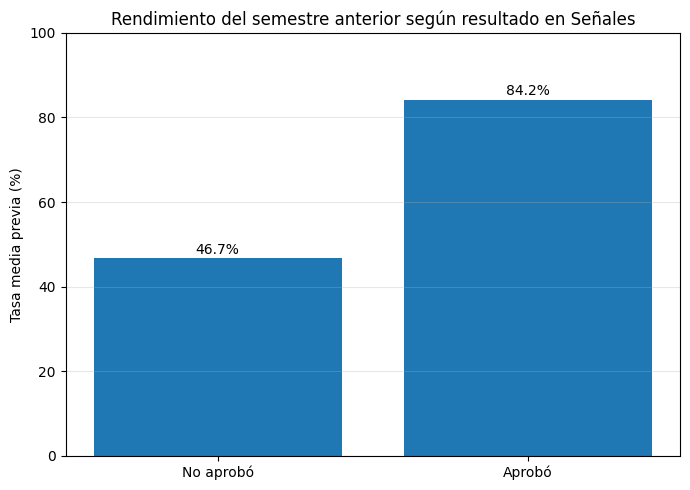

In [15]:
tasas = (
    senales.groupby("y")[
        "tasa_aprobacion_anterior"
    ]
    .mean()
    .sort_index()
    * 100
)

plt.figure(figsize=(7, 5))

barras = plt.bar(
    ["No aprobó", "Aprobó"],
    tasas.values
)

for barra, valor in zip(
    barras,
    tasas.values
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 1,
        f"{valor:.1f}%",
        ha="center"
    )

plt.ylim(0, 100)
plt.ylabel("Tasa media previa (%)")
plt.title(
    "Rendimiento del semestre anterior según resultado en Señales"
)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Gráfico 7 — Primer Parcial vs rendimiento previo

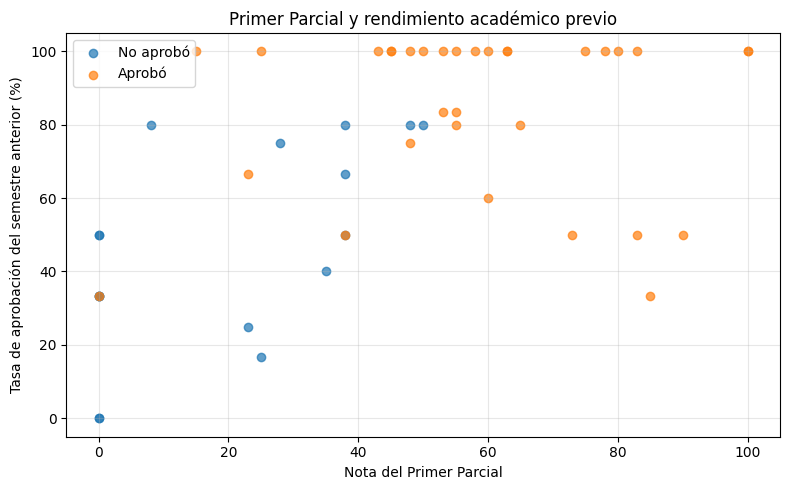

In [16]:
plt.figure(figsize=(8, 5))

for clase, etiqueta in [
    (0, "No aprobó"),
    (1, "Aprobó")
]:

    datos = senales[
        senales["y"] == clase
    ]

    plt.scatter(
        datos["Primer.Par"],
        datos["tasa_aprobacion_anterior"] * 100,
        alpha=0.7,
        label=etiqueta
    )

plt.xlabel("Nota del Primer Parcial")
plt.ylabel("Tasa de aprobación del semestre anterior (%)")
plt.title("Primer Parcial y rendimiento académico previo")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 8. Prerrequisitos

- Malla vieja `MCT-PLS13`: Métodos Numéricos.
- Malla nueva `MCT-PLS23`: Métodos Numéricos + Estadística.

La nota se extrae desde `Nota.Final`.

Se estudian como parte del feature engineering, pero **no se incorporan al modelo principal** si la cobertura histórica es insuficiente, porque la base comienza en 2024-1.

In [17]:
df["periodo"] = (
    df["Anho"] * 2
    + df["Semestre"]
)

senales["periodo"] = (
    senales["Anho"] * 2
    + senales["Semestre"]
)

# Filtrar una sola vez las materias prerrequisito.
# Esto evita recorrer toda la base de 87 mil filas para cada alumno.
prerrequisitos_hist = df[
    df["Asignatura_norm"].isin([
        "METODOS NUMERICOS",
        "ESTADISTICA"
    ])
].copy()

prerrequisitos_hist = (
    prerrequisitos_hist
    .sort_values([
        "ALUMNO_ID",
        "periodo",
        "Convocatoria"
    ])
)


def ultima_nota_previa(
    alumno_id,
    periodo_actual,
    asignatura_norm
):

    historia = prerrequisitos_hist[
        (prerrequisitos_hist["ALUMNO_ID"] == alumno_id)
        &
        (prerrequisitos_hist["periodo"] < periodo_actual)
        &
        (
            prerrequisitos_hist["Asignatura_norm"]
            == asignatura_norm
        )
    ]

    if historia.empty:
        return np.nan

    notas_validas = (
        historia["NotaFinal_num"]
        .dropna()
    )

    if notas_validas.empty:
        return np.nan

    return float(
        notas_validas.iloc[-1]
    )


notas_metodos = []
notas_estadistica = []

for _, fila in senales.iterrows():

    uid = fila["ALUMNO_ID"]
    periodo_actual = fila["periodo"]

    nota_mn = ultima_nota_previa(
        uid,
        periodo_actual,
        "METODOS NUMERICOS"
    )

    if fila["malla_nueva"] == 1:

        nota_est = ultima_nota_previa(
            uid,
            periodo_actual,
            "ESTADISTICA"
        )

    else:

        nota_est = np.nan

    notas_metodos.append(nota_mn)
    notas_estadistica.append(nota_est)


senales["nota_metodos_numericos"] = (
    notas_metodos
)

senales["nota_estadistica"] = (
    notas_estadistica
)

senales["promedio_prerrequisitos"] = np.where(
    senales["malla_nueva"] == 0,
    senales["nota_metodos_numericos"],
    (
        senales["nota_metodos_numericos"]
        + senales["nota_estadistica"]
    ) / 2
)

cobertura_mn = (
    100
    * senales[
        "nota_metodos_numericos"
    ]
    .notna()
    .mean()
)

mask_nueva = (
    senales["malla_nueva"] == 1
)

cobertura_est = (
    100
    * senales.loc[
        mask_nueva,
        "nota_estadistica"
    ]
    .notna()
    .mean()
)

cobertura_completa = (
    100
    * senales[
        "promedio_prerrequisitos"
    ]
    .notna()
    .mean()
)

print(
    f"Cobertura Métodos Numéricos: "
    f"{cobertura_mn:.1f}%"
)

print(
    f"Cobertura Estadística en malla nueva: "
    f"{cobertura_est:.1f}%"
)

print(
    f"Cobertura completa de prerrequisitos: "
    f"{cobertura_completa:.1f}%"
)

Cobertura Métodos Numéricos: 71.4%
Cobertura Estadística en malla nueva: 46.2%
Cobertura completa de prerrequisitos: 59.2%


## Gráfico 8 — Cobertura de prerrequisitos

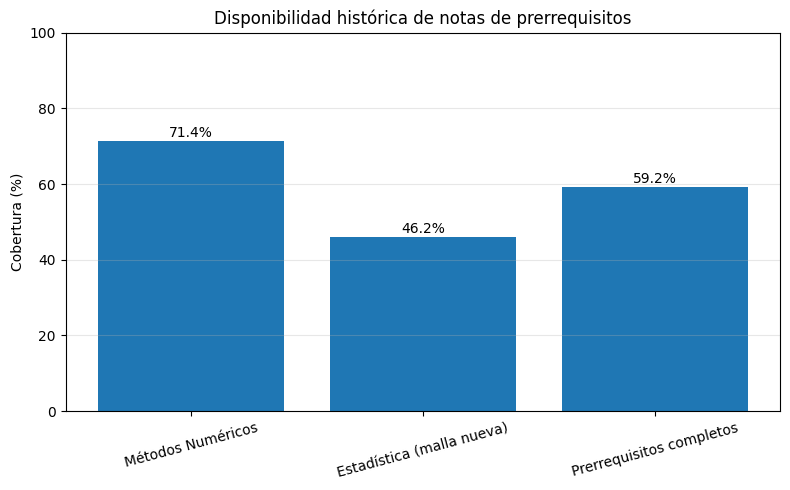

In [18]:
nueva_total = int(mask_nueva.sum())

cobertura_tabla = pd.DataFrame({
    "Variable": [
        "Métodos Numéricos",
        "Estadística (malla nueva)",
        "Prerrequisitos completos"
    ],
    "Cobertura": [
        cobertura_mn,
        cobertura_est,
        cobertura_completa
    ]
})

plt.figure(figsize=(8, 5))

barras = plt.bar(
    cobertura_tabla["Variable"],
    cobertura_tabla["Cobertura"]
)

for barra, valor in zip(
    barras,
    cobertura_tabla["Cobertura"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 1,
        f"{valor:.1f}%",
        ha="center"
    )

plt.ylim(0, 100)
plt.ylabel("Cobertura (%)")
plt.title("Disponibilidad histórica de notas de prerrequisitos")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Variables finales del modelo

### Baseline
- `Primer.Par`

### Modelo con feature engineering
- `Primer.Par`
- `materias_cursadas_anterior`
- `materias_aprobadas_anterior`
- `tasa_aprobacion_anterior`

Se excluyen del modelo:

- `Nota.Final`
- segundo parcial;
- recuperatorios;
- firma;
- cualquier dato posterior al primer parcial.

`Nota.Final` se usa **solo para construir el target**, nunca como predictor.

In [55]:
# ============================================================
# VARIABLES DE ENTRADA DEL MODELO
# ============================================================

features_baseline = [
    "Primer.Par"
]

features_final = [
    "Primer.Par",
    "materias_cursadas_anterior",
    "materias_aprobadas_anterior",
    "tasa_aprobacion_anterior"
]


# Variables predictoras
X = senales_modelo[
    features_final
].copy()

# Variable objetivo
y = senales_modelo[
    "y"
].copy()


print("Dimensiones de X:")
print(X.shape)

print("\nVariables utilizadas:")
print(X.columns.tolist())

print("\nEstadísticas:")
display(
    X.describe().round(3)
)

NameError: name 'senales_modelo' is not defined

## Gráfico 9 — Matriz de correlación de las variables del modelo

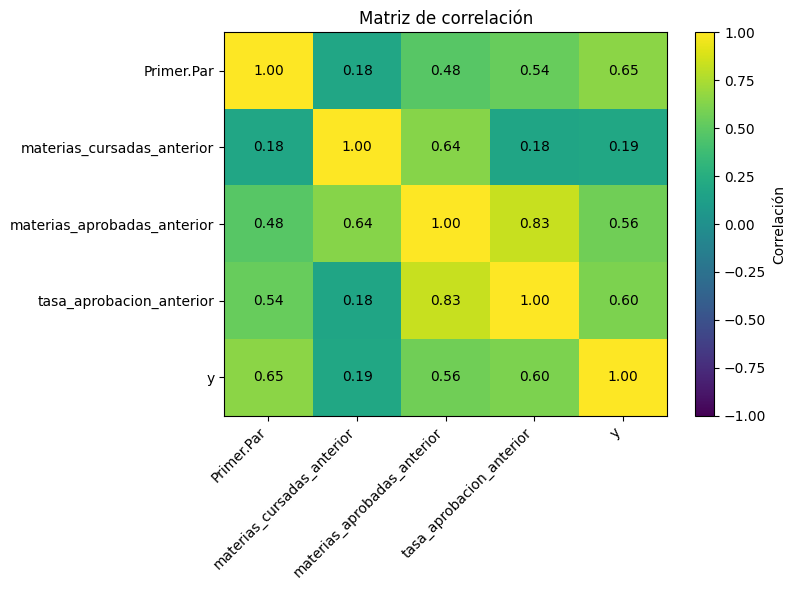

In [20]:
corr_df = (
    senales[
        features_final + ["y"]
    ]
    .corr()
)

plt.figure(figsize=(8, 6))

imagen = plt.imshow(
    corr_df.values,
    vmin=-1,
    vmax=1,
    aspect="auto"
)

plt.colorbar(
    imagen,
    label="Correlación"
)

plt.xticks(
    range(len(corr_df.columns)),
    corr_df.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr_df.index)),
    corr_df.index
)

for i in range(len(corr_df.index)):
    for j in range(len(corr_df.columns)):
        plt.text(
            j,
            i,
            f"{corr_df.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

# 10. Separación entrenamiento/prueba por grupos

Como el conjunto es pequeño y existen perfiles que aparecen en más de un año, se usa `StratifiedGroupKFold`.

Esto permite:

1. conservar aproximadamente la proporción de aprobados/no aprobados;
2. evitar que el mismo perfil académico aparezca en train y test.

Cada fold contiene un conjunto de entrenamiento y un conjunto de prueba.

In [21]:
splitter = StratifiedGroupKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    splitter.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Entrenamiento:", len(X_train))
print("Prueba:", len(X_test))

print("\nClases en entrenamiento:")
print(y_train.value_counts())

print("\nClases en prueba:")
print(y_test.value_counts())

Entrenamiento: 33
Prueba: 16

Clases en entrenamiento:
y
1    21
0    12
Name: count, dtype: int64

Clases en prueba:
y
1    11
0     5
Name: count, dtype: int64


# 11. Entrenamiento de tres modelos

In [22]:
modelos = {

    "Regresión Logística": Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "modelo",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]),

    "Árbol de Decisión": Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "modelo",
            DecisionTreeClassifier(
                max_depth=3,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]),

    "Random Forest": Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=150,
                max_depth=4,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=1
            )
        )
    ])
}

# 12. Evaluación sobre el primer conjunto de prueba

In [23]:
resultados = []
predicciones = {}
probabilidades = {}

for nombre, modelo in modelos.items():

    modelo.fit(
        X_train,
        y_train
    )

    y_pred = modelo.predict(
        X_test
    )

    y_prob = modelo.predict_proba(
        X_test
    )[:, 1]

    predicciones[nombre] = y_pred
    probabilidades[nombre] = y_prob

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(
            y_test,
            y_pred
        ),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_test,
            y_prob
        )
    })

resultados_df = (
    pd.DataFrame(resultados)
    .sort_values(
        ["F1", "ROC_AUC"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    resultados_df.round(3)
)

,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,Regresión Logística,1.000,1.000,1.000,1.000,1.000
1,Random Forest,1.000,1.000,1.000,1.000,1.000
2,Árbol de Decisión,0.938,1.000,0.909,0.952,0.936


In [31]:
print(features_final)

['Primer.Par', 'materias_cursadas_anterior', 'materias_aprobadas_anterior', 'tasa_aprobacion_anterior']


## Gráfico 10 — Comparación de métricas de los modelos

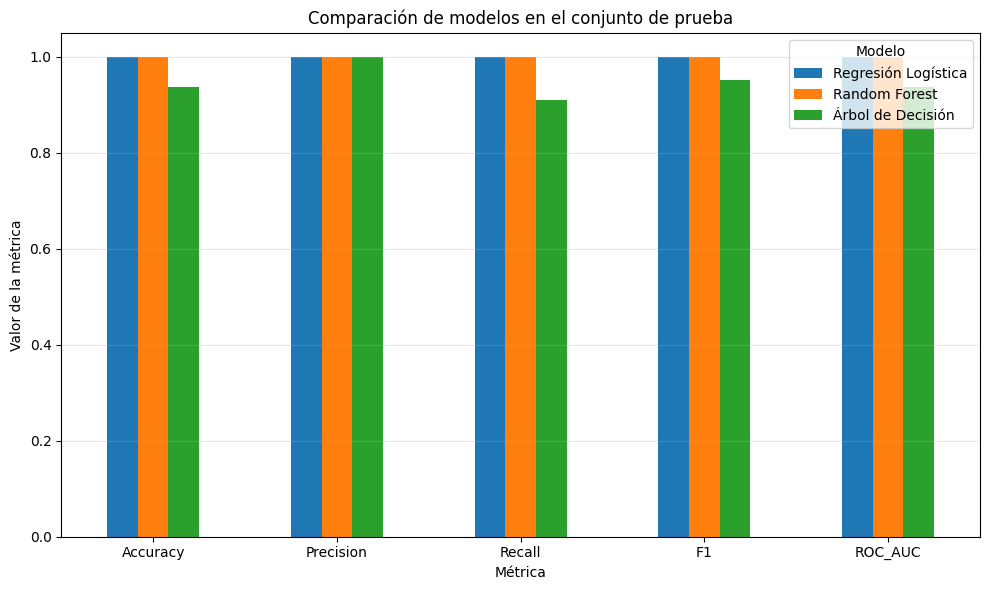

In [24]:
metricas_largo = (
    resultados_df
    .set_index("Modelo")[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "ROC_AUC"
        ]
    ]
)

ax = metricas_largo.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("Valor de la métrica")
plt.xlabel("Métrica")
plt.title("Comparación de modelos en el conjunto de prueba")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Modelo")
plt.tight_layout()
plt.show()

## Gráfico 11 — Curvas ROC

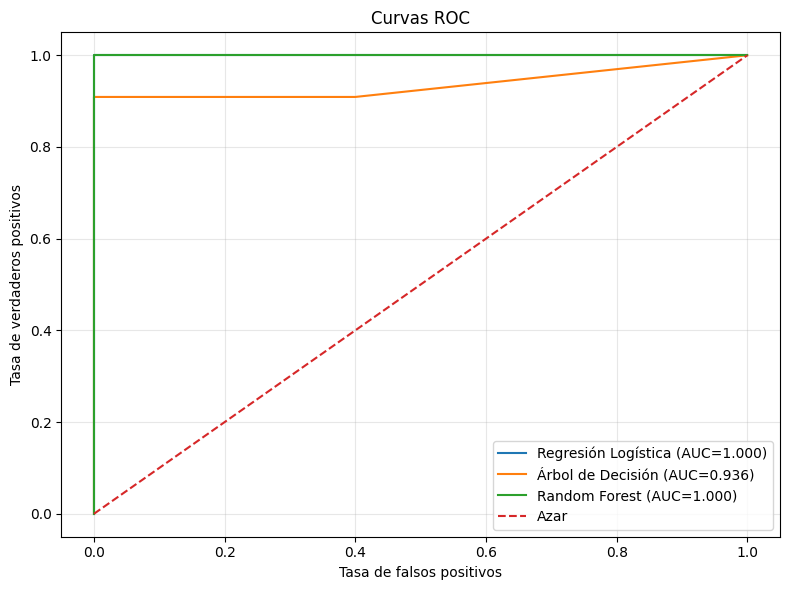

In [25]:
plt.figure(figsize=(8, 6))

for nombre in modelos.keys():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilidades[nombre]
    )

    auc = roc_auc_score(
        y_test,
        probabilidades[nombre]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{nombre} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Azar"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curvas ROC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Gráfico 12 — Matriz de confusión del mejor modelo del primer test

Se selecciona aquí por `F1`.

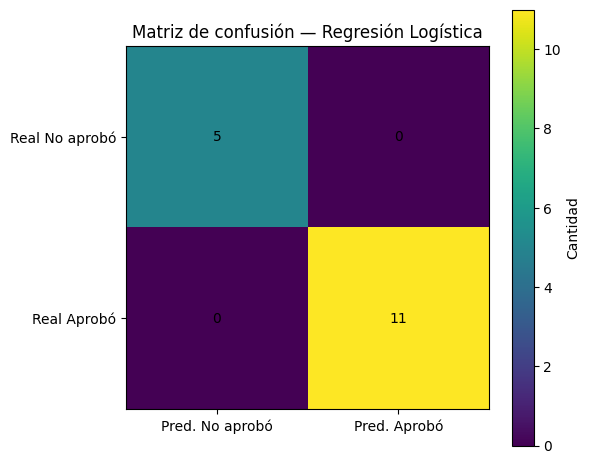

              precision    recall  f1-score   support

   No aprobó       1.00      1.00      1.00         5
      Aprobó       1.00      1.00      1.00        11

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16



In [26]:
mejor_modelo_test = (
    resultados_df.iloc[0]["Modelo"]
)

mejor_pred = (
    predicciones[
        mejor_modelo_test
    ]
)

matriz = confusion_matrix(
    y_test,
    mejor_pred
)

plt.figure(figsize=(6, 5))

imagen = plt.imshow(
    matriz
)

plt.colorbar(
    imagen,
    label="Cantidad"
)

plt.xticks(
    [0, 1],
    [
        "Pred. No aprobó",
        "Pred. Aprobó"
    ]
)

plt.yticks(
    [0, 1],
    [
        "Real No aprobó",
        "Real Aprobó"
    ]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            str(matriz[i, j]),
            ha="center",
            va="center"
        )

plt.title(
    f"Matriz de confusión — {mejor_modelo_test}"
)

plt.tight_layout()
plt.show()

print(
    classification_report(
        y_test,
        mejor_pred,
        target_names=[
            "No aprobó",
            "Aprobó"
        ],
        zero_division=0
    )
)

# 13. Comparación robusta: baseline vs feature engineering

Con pocos datos es peligroso concluir a partir de una sola partición.

Por eso se evalúan los tres modelos en **tres folds**, siempre separando por perfil académico.

Se comparan:

- `Baseline_P1`: solo el primer parcial.
- `P1_mas_historial`: primer parcial + rendimiento del semestre anterior.

In [27]:
comparaciones = []

for fold, (tr, te) in enumerate(
    splitter.split(
        np.zeros(len(senales)),
        senales["y"],
        groups=senales["profile_group"]
    ),
    start=1
):

    experimentos = {
        "Baseline_P1": features_baseline,
        "P1_mas_historial": features_final
    }

    for experimento, columnas in experimentos.items():

        for nombre, modelo in modelos.items():

            # Clonar para que cada fold empiece con un modelo limpio
            modelo_fold = clone(modelo)

            modelo_fold.fit(
                senales.iloc[tr][columnas],
                senales.iloc[tr]["y"]
            )

            pred = modelo_fold.predict(
                senales.iloc[te][columnas]
            )

            prob = modelo_fold.predict_proba(
                senales.iloc[te][columnas]
            )[:, 1]

            comparaciones.append({
                "Fold": fold,
                "Experimento": experimento,
                "Modelo": nombre,
                "Accuracy": accuracy_score(
                    senales.iloc[te]["y"],
                    pred
                ),
                "F1": f1_score(
                    senales.iloc[te]["y"],
                    pred,
                    zero_division=0
                ),
                "ROC_AUC": roc_auc_score(
                    senales.iloc[te]["y"],
                    prob
                )
            })

comparacion_df = pd.DataFrame(
    comparaciones
)

promedios = (
    comparacion_df
    .groupby([
        "Experimento",
        "Modelo"
    ])[
        [
            "Accuracy",
            "F1",
            "ROC_AUC"
        ]
    ]
    .mean()
    .reset_index()
    .sort_values(
        [
            "Experimento",
            "F1"
        ],
        ascending=[
            True,
            False
        ]
    )
)

display(
    promedios.round(3)
)

,Experimento,Modelo,Accuracy,F1,ROC_AUC
1,Baseline_P1,Regresión Logística,0.836,0.871,0.922
0,Baseline_P1,Random Forest,0.757,0.800,0.856
2,Baseline_P1,Árbol de Decisión,0.759,0.795,0.839
4,P1_mas_historial,Regresión Logística,0.877,0.906,0.904
3,P1_mas_historial,Random Forest,0.877,0.900,0.905
5,P1_mas_historial,Árbol de Decisión,0.837,0.865,0.865


## Gráfico 13 — Efecto del feature engineering sobre F1

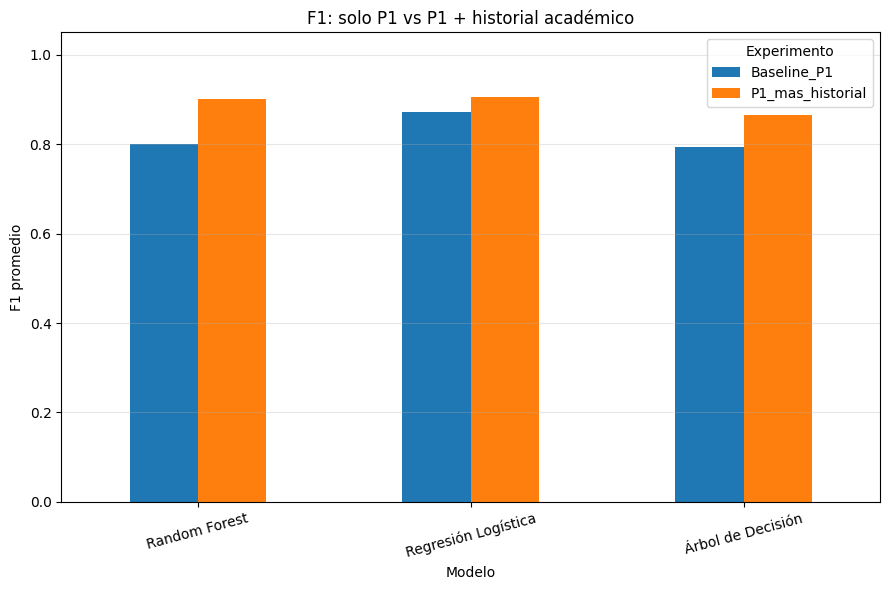

In [28]:
tabla_f1 = (
    promedios.pivot(
        index="Modelo",
        columns="Experimento",
        values="F1"
    )
)

ax = tabla_f1.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.ylim(0, 1.05)
plt.ylabel("F1 promedio")
plt.xlabel("Modelo")
plt.title("F1: solo P1 vs P1 + historial académico")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Experimento")
plt.tight_layout()
plt.show()

# 14. Importancia de variables del Random Forest

La importancia indica cuánto usa el modelo una variable para predecir.  
**No implica causalidad.**

,Importancia
Primer.Par,0.435
tasa_aprobacion_anterior,0.275
materias_aprobadas_anterior,0.215
materias_cursadas_anterior,0.074


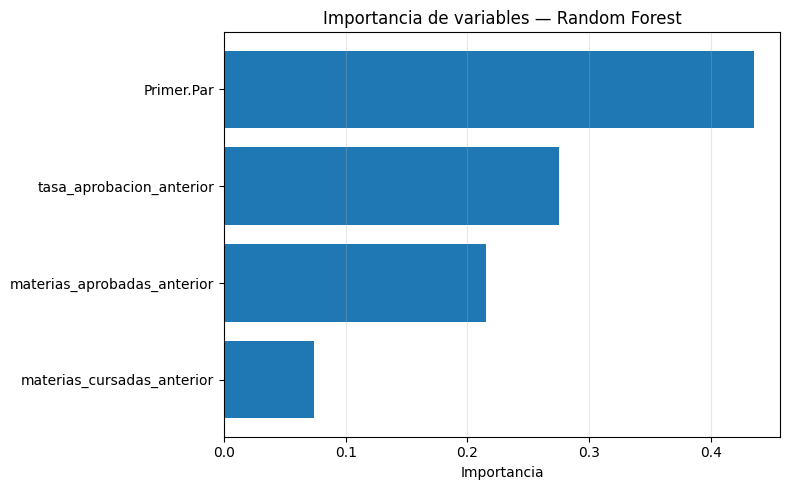

In [29]:
rf_final = modelos[
    "Random Forest"
]

rf_final.fit(
    X_train,
    y_train
)

importancias = pd.Series(
    rf_final
    .named_steps["modelo"]
    .feature_importances_,
    index=features_final
).sort_values(
    ascending=False
)

display(
    importancias
    .rename("Importancia")
    .to_frame()
    .round(3)
)

plt.figure(figsize=(8, 5))

plt.barh(
    importancias.index[::-1],
    importancias.values[::-1]
)

plt.xlabel("Importancia")
plt.title("Importancia de variables — Random Forest")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# 15. Selección del modelo y conclusiones

Para una conclusión más estable se recomienda seleccionar el modelo usando el **F1 promedio de los tres folds** del experimento `P1_mas_historial`.

El primer test se conserva porque muestra de manera concreta cómo se evalúa un conjunto de prueba; el promedio de folds ayuda a no depender de una sola división aleatoria.

In [30]:
ranking_final = (
    promedios[
        promedios[
            "Experimento"
        ]
        == "P1_mas_historial"
    ]
    .sort_values(
        "F1",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    ranking_final.round(3)
)

mejor_modelo_cv = (
    ranking_final.iloc[0]["Modelo"]
)

print(
    "Modelo recomendado según F1 promedio:",
    mejor_modelo_cv
)

,Experimento,Modelo,Accuracy,F1,ROC_AUC
0,P1_mas_historial,Regresión Logística,0.877,0.906,0.904
1,P1_mas_historial,Random Forest,0.877,0.900,0.905
2,P1_mas_historial,Árbol de Decisión,0.837,0.865,0.865


Modelo recomendado según F1 promedio: Regresión Logística
